In [26]:
import pickle
import random
import warnings
import matplotlib.pyplot as plt
from matplotlib import rcParams
from cmcrameri import cm
import seaborn as sns
from pandas import DataFrame, read_parquet
from numpy import arange, array, isnan
import statsmodels.api as sm
from IPython.display import Markdown, display

import func_gev as gev
import func_preparation as dbf
import func_plotting as dbplt
import func_utils as ut

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

fs = 12
rcParams['font.family'] = [
    'Noto Sans',
    'Noto Sans Arabic',
    'Noto Sans Tifinagh',
    'Noto Sans CJK JP',
    'Noto Sans Devanagari'
]
sns.set_style('whitegrid')

# Settings

In [29]:
dir_fit = '../output/gev_analysis/pooled/2026-02-06/fit results.pkl'
dir_data = '../output/gev_analysis/pooled/2026-02-06/data.parquet'

In [3]:
axes_color: str = '#333333'
markers_color: str = "#99E3DDFF"
colors_reg: list = ['#333333FF', '#7F6C7BFF']  

In [4]:
# adding a little randomness to enhance trust the model works as robust as possible cross locations..
start_location = random.choice(arange(0, 9579))
end_location = start_location+10

print(f'analyse a subsample of location {start_location}–{end_location}')

analyse a subsample of location 2814–2824


# Load Fit Results

In [30]:
with open(dir_data, 'rb') as file:
    data = read_parquet(file)

In [27]:
with open(dir_fit, 'rb') as file:
    fit_results = pickle.load(file)

In [ ]:
if start_location is not None or end_location is not None: 
    fit_results_cropped = ut.select_allowed_locations(
        dic_data_per_location=fit_results, 
        start_loc=start_location, end_loc=end_location
        )
    print(f'Processing locations {start_location} to {end_location} ({len(fit_results)} total)')

else:
    print(f'Processing all {len(fit_results)} locations')


Processing locations 2814 to 2824 (9589 total)


# Data Processing...

In [ ]:
site_ex = random.choice(list(fit_results_cropped.keys()))
print(f'using siteID {site_ex} for inspection')

using siteID 2818 for inspection


In [ ]:
fit_results_cropped[site_ex].keys()

dict_keys(['gev_stationary', 'gev_nonstationary'])

In [ ]:
df_non_stationary = fit_results_cropped[site_ex]['gev_nonstationary']
df_non_stationary

{'mu0': np.float64(0.8633305972998981),
 'mu1': np.float64(0.00208687291109706),
 'sigma': np.float64(0.1640031466076022),
 'xi': np.float64(-0.20528349970085658),
 'trend_in': 'location',
 'n_obs': 5457,
 'log_likelihood': np.float64(2021.943870355094),
 'aic': np.float64(-4035.887740710188),
 'bic': np.float64(-4009.469122841443),
 'years_mean': np.float64(1994.0700018325088),
 'years_std': np.float64(16.672008998833075),
 'CI': {'mu_pred': array([0.85919115, 0.85919115, 0.85919115, ..., 0.86732735, 0.86732735,
         0.86732735], shape=(5457,)),
  'mu_lower': array([0.84920011, 0.84920011, 0.84920011, ..., 0.85784258, 0.85784258,
         0.85784258], shape=(5457,)),
  'mu_upper': array([0.86918219, 0.86918219, 0.86918219, ..., 0.87681211, 0.87681211,
         0.87681211], shape=(5457,))}}

In [ ]:
df_annual_location = fit_results_cropped[site_ex]['gev_stationary']['analysis_per_year']
df_annual_location

,shape,location,scale,n_obs,log_likelihood,aic,bic,dist_type,tail_behavior
1962,-1.036664,0.823422,0.137877,16,16.661734,-27.323468,-25.005702,Weibull (Type III),Light (bounded)
1963,0.1253,0.81139,0.091618,24,17.664914,-29.329827,-25.795666,Fréchet (Type II),Heavy (polynomial)
1964,-0.251848,0.886865,0.152221,31,13.977377,-21.954755,-17.652793,Weibull (Type III),Light (bounded)
1965,-0.114501,0.896291,0.151412,38,14.095356,-22.190713,-17.277954,Weibull (Type III),Light (bounded)
1966,-0.166855,0.831525,0.135227,48,24.518631,-43.037263,-37.42366,Weibull (Type III),Light (bounded)
...,...,...,...,...,...,...,...,...,...
2022,-0.084114,0.898104,0.13719,59,26.757038,-47.514075,-41.281463,Weibull (Type III),Light (bounded)
2023,-0.202464,0.855655,0.144047,52,25.004881,-44.009763,-38.156032,Weibull (Type III),Light (bounded)
2024,0.075161,0.859423,0.12492,42,19.064143,-32.128286,-26.915277,Fréchet (Type II),Heavy (polynomial)
2025,-0.056152,0.885107,0.13712,34,14.699711,-23.399423,-18.820341,Weibull (Type III),Light (bounded)


In [11]:
x = df_annual_location.index  
y = df_annual_location.location.values * 1000
weights = array(df_annual_location.n_obs.values, dtype=float)

WLS directly incorporates weights (in your case, n_obs) to estimate slope and intercept with their standard errors. So the uncertainty comes from the regression model, not a delta approximation.

In [12]:
wls_model = sm.WLS(y, sm.add_constant(x), weights=weights)
results = wls_model.fit()

In [13]:
conf_int = results.conf_int(alpha=0.05)
print("95% CI for intercept and slope:\n", conf_int)

95% CI for intercept and slope:
 [[-8.06399592e+03  1.02768182e+03]
 [-1.11991937e-01  4.44709577e+00]]


continue - plot non-stationary regression

In [14]:
df_non_stationary

{'mu0': np.float64(0.8633305972998981),
 'mu1': np.float64(0.00208687291109706),
 'sigma': np.float64(0.1640031466076022),
 'xi': np.float64(-0.20528349970085658),
 'trend_in': 'location',
 'n_obs': 5457,
 'log_likelihood': np.float64(2021.943870355094),
 'aic': np.float64(-4035.887740710188),
 'bic': np.float64(-4009.469122841443),
 'years_mean': np.float64(1994.0700018325088),
 'years_std': np.float64(16.672008998833075),
 'CI': {'mu_pred': array([0.85919115, 0.85919115, 0.85919115, ..., 0.86732735, 0.86732735,
         0.86732735], shape=(5457,)),
  'mu_lower': array([0.84920011, 0.84920011, 0.84920011, ..., 0.85784258, 0.85784258,
         0.85784258], shape=(5457,)),
  'mu_upper': array([0.86918219, 0.86918219, 0.86918219, ..., 0.87681211, 0.87681211,
         0.87681211], shape=(5457,))}}

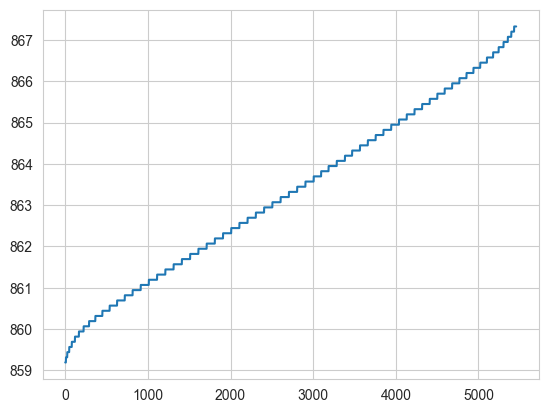

In [25]:
plt.plot(df_non_stationary['CI']['mu_pred']*1000)

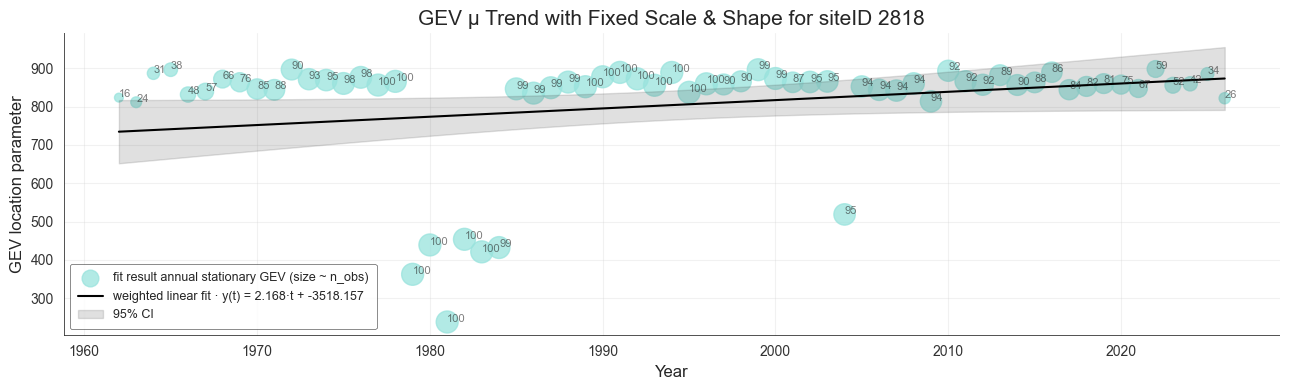

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))

# annual-stationary GEV results
ax.scatter(
        x, y, 
        s=weights*2.5, marker='o', color=markers_color, alpha=0.75, 
        label='fit result annual stationary GEV (size ~ n_obs)'
        )
for idx, row in df_annual_location.iterrows():
        ax.text(idx, row.location*1001, f"{row.n_obs}", fontsize=8, alpha=0.6)

intercept, slope = results.params
plt.plot(
        x, results.predict(sm.add_constant(x)), 
        color='k', label=f'weighted linear fit · y(t) = {slope:.3f}·t + {intercept:.3f}'
        )
pred = results.get_prediction(sm.add_constant(x))
ci = pred.conf_int()
ci = array(ci, dtype=float) 
plt.fill_between(x, ci[:, 0], ci[:, 1], color=colors_reg[0], alpha=0.15, label='95% CI')

# non-stationary GEV
ax.scatter(df_non_stationary['CI']['mu_pred'])

# ----------------------------------------------------------------------------
# layout
leg = ax.legend(loc=0, edgecolor=axes_color, borderpad=.65, fontsize=fs*0.75)
leg.get_frame().set_linewidth(.5)

for spine in ax.spines.values():
        spine.set_visible(False)

ax.axhline(y=ax.get_ylim()[0], color=axes_color, linewidth=1.2, zorder=10)
ax.axvline(x=ax.get_xlim()[0], color=axes_color, linewidth=1.2, zorder=10)

ax.tick_params(axis='x', colors=axes_color)
ax.tick_params(axis='y', colors=axes_color)

ax.grid(True, alpha=0.3, color='lightgrey')
ax.set_title(
f'GEV μ Trend with Fixed Scale & Shape for siteID {site_ex}', 
fontsize=fs*1.25
)
ax.set_xlabel('Year', fontsize=fs)
ax.set_ylabel('GEV location parameter', fontsize=fs)
plt.tight_layout()
